## Importing Dependencies

In [1]:
import os
import json
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pycocotools.coco import COCO


## Global Variables

In [2]:
IMAGE_DIR = "/kaggle/input/whu-building-rooftop-dataset/train"              # folder containing images
ANNOTATION_FILE = "/kaggle/input/whu-building-rooftop-dataset/annotation/train.json"  # COCO JSON file

## Lading the Annotation file

In [3]:
coco = COCO(ANNOTATION_FILE)

print("Number of images:", len(coco.imgs))
print("Number of annotations:", len(coco.anns))
print("Categories:", coco.cats)

loading annotations into memory...
Done (t=2.28s)
creating index...
index created!
Number of images: 2943
Number of annotations: 143252
Categories: {1: {'supercategory': 'building', 'id': 1, 'name': 'building'}}


## Total number of annotations per category

In [12]:
cat_ids = coco.getCatIds()

print("Annotations per Category:\n")
for cid in cat_ids:
    cat_name = coco.cats[cid]['name']
    count = len(coco.getAnnIds(catIds=[cid]))
    print(f"{cat_name}: {count}")


Annotations per Category:

building: 143252


## Image resolution distribution

In [13]:
resolutions = [(img['width'], img['height']) for img in coco.imgs.values()]
resolution_counts = Counter(resolutions)

print("Image Resolution Distribution:\n")
for (w, h), count in resolution_counts.items():
    print(f"{w} x {h} : {count} images")

Image Resolution Distribution:

1024 x 1024 : 2943 images


## Visualizing some random images

In [14]:
def show_random_images(n=3):
    img_ids = random.sample(list(coco.imgs.keys()), n)
    plt.figure(figsize=(15,5))

    for i, img_id in enumerate(img_ids):
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(IMAGE_DIR, img_info['file_name'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_info['file_name'])

    plt.show()

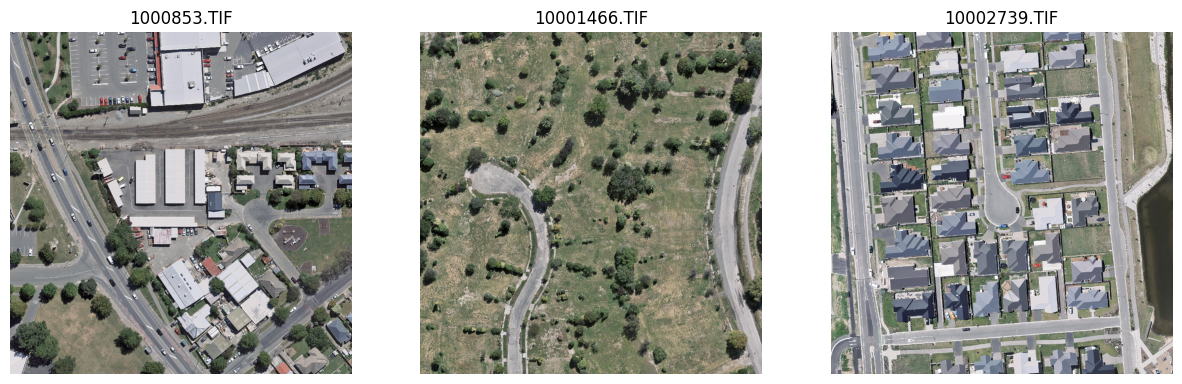

In [15]:
show_random_images(3)

## Visualizing some images with masks

In [7]:
def show_image_with_mask(img_id):
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(IMAGE_DIR, img_info['file_name'])

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))
    mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)

    for ann in anns:
        mask |= coco.annToMask(ann)

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Segmentation Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    overlay = image.copy()
    overlay[mask == 1] = [255, 0, 0]
    plt.imshow(overlay)
    plt.title("Overlay (Rooftops)")
    plt.axis("off")

    plt.show()


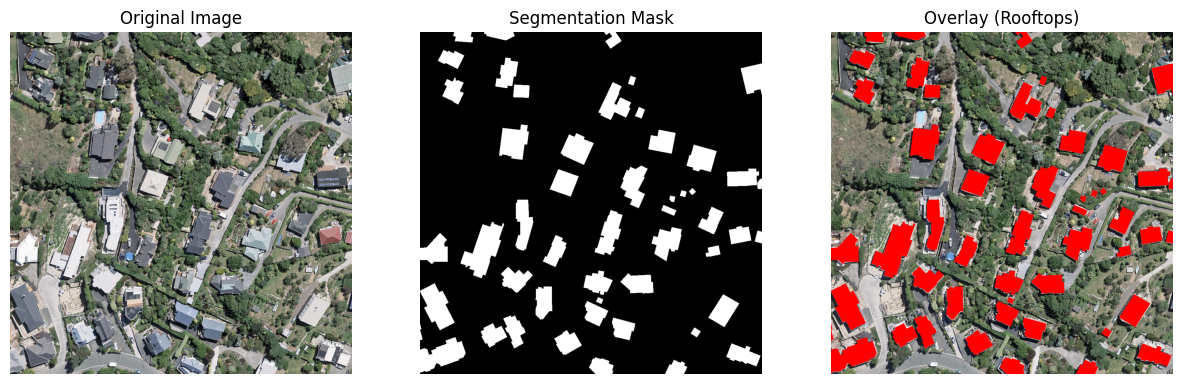

In [8]:
# Test on a random image
random_img_id = random.choice(list(coco.imgs.keys()))
show_image_with_mask(random_img_id)

## Visualizing with bounding boxes

In [9]:
def show_bounding_boxes(img_id):
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(IMAGE_DIR, img_info['file_name'])

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))

    for ann in anns:
        x, y, w, h = ann['bbox']
        cv2.rectangle(image, (int(x), int(y)), 
                       (int(x+w), int(y+h)), (0,255,0), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Bounding Boxes")
    plt.show()


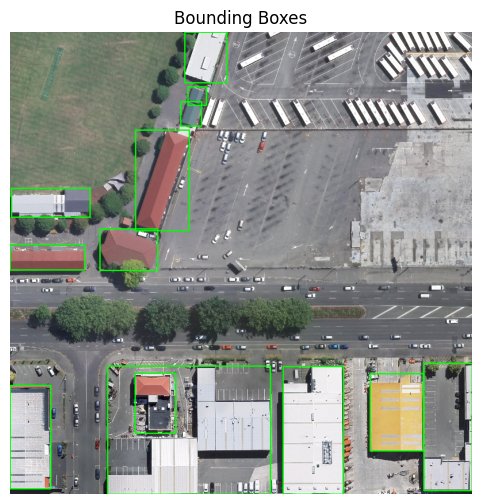

In [11]:
random_img_id = random.choice(list(coco.imgs.keys()))
show_bounding_boxes(random_img_id)

## Rooftop area distribution

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


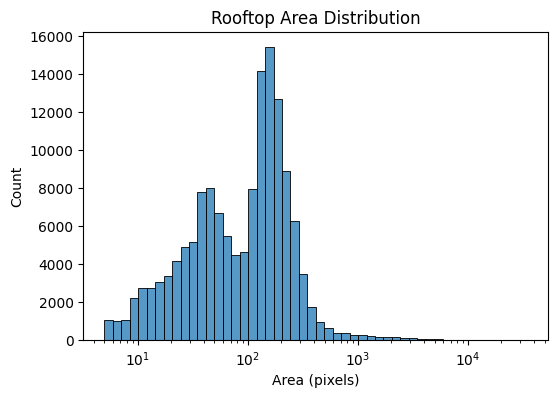

In [10]:
areas = [ann['area'] for ann in coco.anns.values()]

plt.figure(figsize=(6,4))
sns.histplot(areas, bins=50, log_scale=True)
plt.title("Rooftop Area Distribution")
plt.xlabel("Area (pixels)")
plt.show()
